# Capstone Project - Stage 2, Week 1 (Module 12)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ConstantKernel
from sklearn.preprocessing import StandardScaler

from scipy.stats import norm
from scipy.spatial.distance import pdist
from scipy.stats import qmc


## Function 1

**2-dimensional**

Detect likely contamination sources in a two-dimensional area, such as a radiation field, where only proximity yields a non-zero reading. The system uses Bayesian optimisation to tune detection parameters and reliably identify both strong and weak sources.

**Approach**:

Start with high kappa, use RBF kernel.

### Loading data

In [2]:
function1_inputs = np.load('C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/initial_data/function_1/initial_inputs.npy')
print('Inputs: \n',function1_inputs)

function1_outputs = np.load('C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/initial_data/function_1/initial_outputs.npy')
print('Outputs: \n',function1_outputs)

print(type(function1_outputs))

X = function1_inputs
y = function1_outputs

#Scaling data
#X = StandardScaler().fit_transform(function1_inputs)
#Note: decided not to scale.


Inputs: 
 [[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]]
Outputs: 
 [ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048]
<class 'numpy.ndarray'>


#### Applying a basic GP model

c:\Python\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


The next query point is: [0.914286 0.804924]


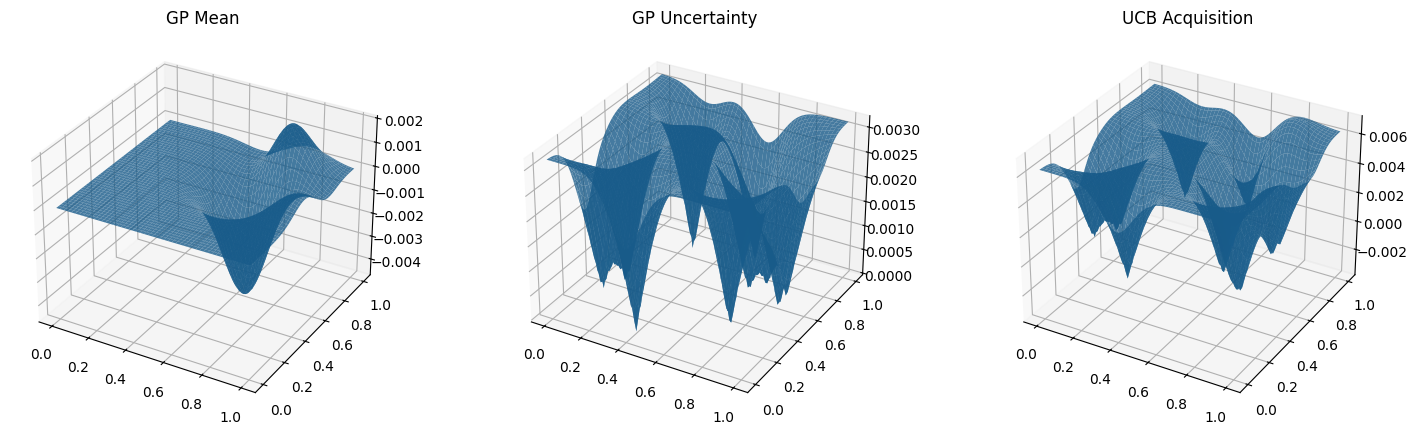

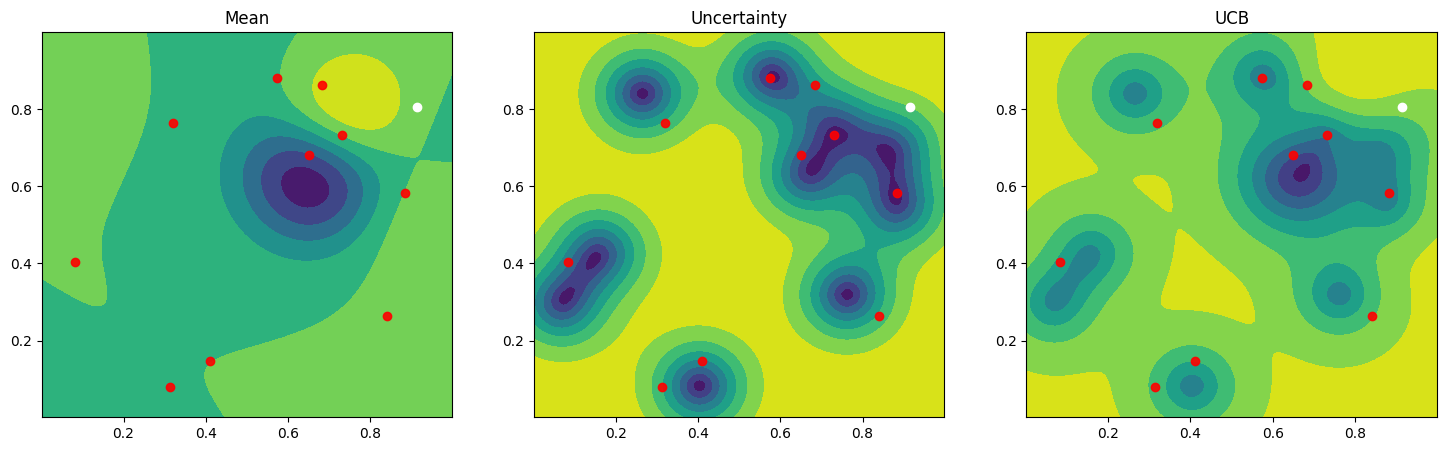

In [6]:
# Defining GP model and fitting to data
kernel = ConstantKernel(1.0) * RBF(length_scale=1)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=12) # Look at parameters, some are interesting like normalise y.

model = gpr.fit(X, y)

# Generating candidate points (grid search)
X_candidates = np.random.uniform(0, 1, (20000, 2))

# GP predictions
mu, sigma = model.predict(X_candidates, return_std=True)

# Acquisition function (UCB)
kappa = 2
acquisition_function = mu + kappa * sigma

# Pick next point
x_next = X_candidates[np.argmax(acquisition_function)]

print('The next query point is:', np.round(x_next, 6))




# ==== Visualising Results ====

# Meshgrid - using grid for plotting but not for actual predictions.

epsilon = 1e-3
x1 = np.linspace(0+epsilon, 1-epsilon, 100)
x2 = np.linspace(0+epsilon, 1-epsilon, 100)

x_grid = np.array([[a, b] for a in x1 for b in x2])

mu_plot, sigma_plot = model.predict(x_grid, return_std=True)

acquisition_plot = mu_plot + kappa * sigma_plot

X1, X2 = np.meshgrid(x1, x2)
X_grid = np.vstack([X1.ravel(), X2.ravel()]).T

# Reshaping
mu = mu_plot.reshape(X1.shape)
sigma = sigma_plot.reshape(X1.shape)
ucb = acquisition_plot.reshape(X1.shape)

#Plotting
fig = plt.figure(figsize=(18, 5))

# Mean
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(X1, X2, mu, alpha=0.8)
#ax1.plot(function1_inputs, function1_outputs)
ax1.set_title("GP Mean")

# Uncertainty
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(X1, X2, sigma, alpha=0.8)
ax2.set_title("GP Uncertainty")

# Acquisition
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_surface(X1, X2, ucb, alpha=0.8)
ax3.set_title("UCB Acquisition")


# Contour plot
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].contourf(X1, X2, mu)
axs[0].scatter(X[:,0], X[:,1], c='red', alpha=0.9)
axs[0].scatter(x_next[0], x_next[1], c="#FFFFFF")
axs[0].set_title("Mean")

axs[1].contourf(X1, X2, sigma)
axs[1].scatter(X[:,0], X[:,1], c='red', alpha=0.9)
axs[1].scatter(x_next[0], x_next[1], c="#FFFFFF")
axs[1].set_title("Uncertainty")

axs[2].contourf(X1, X2, ucb)
axs[2].scatter(X[:,0], X[:,1], c='red', alpha=0.9)
axs[2].scatter(x_next[0], x_next[1], c="#FFFFFF")
axs[2].set_title("UCB")

plt.show()

#### Notes/Findings

Figured out we don't want to scale X, since it creates mapping confusion - the output would be scaled and would therefore need to be unscaled. Was creating issues in plots where curves did not map to actual values - became harder to gain a visual intuition for the function.
Better idea is to scale y if the y values are either very large or very skewed (not the case here).

Changed mesh size from 1000 in each dimension to 100 since it was slow and memory heavy.
Recommendation: 50-100 per dimension.
Better approach might be: X_candidates = np.random.uniform(0, 1, (5000, 2))
- Scales better to high dimensions
- Avoids grid explosion

Use UCB for the first 4-5 rounds since it is heavy on exploration, then can switch to EI for a more exploitative approach to get an accurate result.

## Function 2

**2-dimensional**

Imagine a black box, or a mystery ML model, that takes two numbers as input and returns a log-likelihood score. Your goal is to maximise that score, but each output is noisy, and depending on where you start, you might get stuck in a local optimum. 
To tackle this, you use Bayesian optimisation, which selects the next inputs based on what it has learned so far. It balances exploration with exploitation, making it well suited to noisy outputs and complex functions with many local peaks.

**Approach**:

Potentially multiple peaks, start with high kappa. RBF kernel.

#### Importing data

In [ ]:
function2_inputs = np.load('C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/initial_data/function_2/initial_inputs.npy')
print('Inputs: \n', function2_inputs)

function2_outputs = np.load('C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/initial_data/function_2/initial_outputs.npy')
print('Outputs: \n',function2_outputs)

X = function2_inputs
y = function2_outputs

print(len(X), len(y))

Inputs: 
 [[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]]
Outputs: 
 [ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522]
10 10


#### Surrogate and Acquisition functions

The next query point is: [0.83360779 0.99911687]


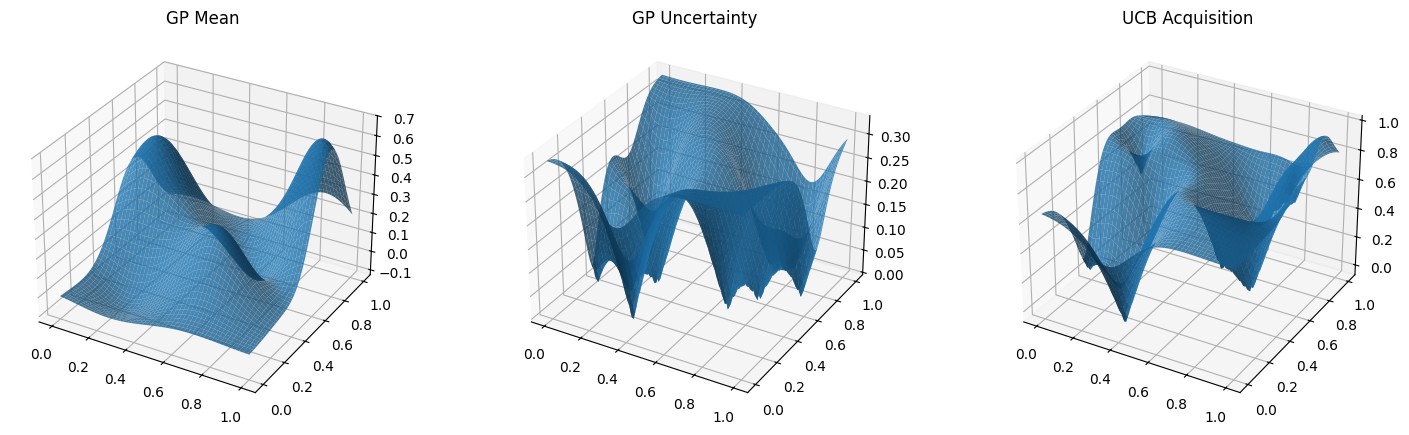

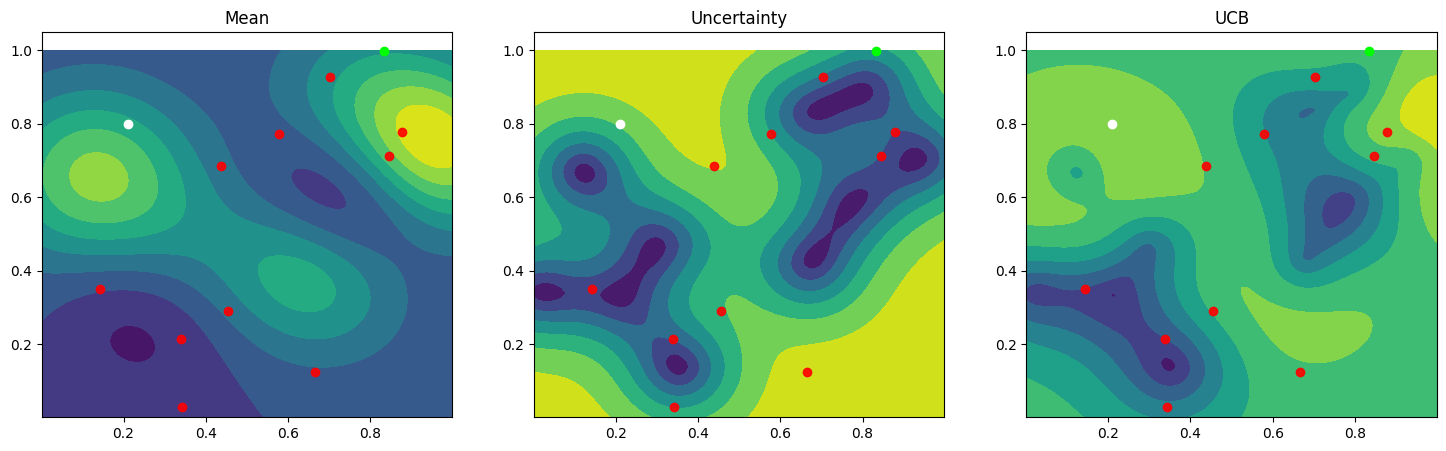

In [ ]:
# Defining GP model and fitting to data
kernel = ConstantKernel(1.0) * RBF(length_scale=1)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=15) # Look at parameters, some are interesting like normalise y.

model = gpr.fit(X, y)

# Generating candidate points (grid search)
X_candidates = np.random.uniform(0, 1, (20000, 2))

# GP predictions
mu, sigma = model.predict(X_candidates, return_std=True)

# Acquisition function (UCB)
kappa = 2
acquisition_function = mu + kappa * sigma

# Pick next point
x_next = X_candidates[np.argmax(acquisition_function)]

print('The next query point is:', np.round(x_next,6))

manual_search = [0.21,0.8]



# ==== Visualising Results ====

# Meshgrid - using grid for plotting but not for actual predictions.

epsilon = 1e-3
x1 = np.linspace(0+epsilon, 1-epsilon, 100)
x2 = np.linspace(0+epsilon, 1-epsilon, 100)

x_grid = np.array([[a, b] for a in x1 for b in x2])

mu_plot, sigma_plot = model.predict(x_grid, return_std=True)

acquisition_plot = mu_plot + kappa * sigma_plot

X1, X2 = np.meshgrid(x1, x2)
X_grid = np.vstack([X1.ravel(), X2.ravel()]).T

# Reshaping
mu = mu_plot.reshape(X1.shape)
sigma = sigma_plot.reshape(X1.shape)
ucb = acquisition_plot.reshape(X1.shape)

# Plotting
fig = plt.figure(figsize=(18, 5))

# Mean
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(X1, X2, mu, alpha=0.8)
#ax1.plot(function1_inputs, function1_outputs)
ax1.set_title("GP Mean")

# Uncertainty
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(X1, X2, sigma, alpha=0.8)
ax2.set_title("GP Uncertainty")

# Acquisition
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_surface(X1, X2, ucb, alpha=0.8)
ax3.set_title("UCB Acquisition")


# Contour plot
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].contourf(X1, X2, mu)
axs[0].scatter(X[:,0], X[:,1], c='red', alpha=0.9)
axs[0].scatter(x_next[0], x_next[1], c='#00FF00')
axs[0].scatter(manual_search[0], manual_search[1], c="#FFFFFF")
axs[0].set_title("Mean")

axs[1].contourf(X1, X2, sigma)
axs[1].scatter(X[:,0], X[:,1], c='red', alpha=0.9)
axs[1].scatter(x_next[0], x_next[1], c='#00FF00')
axs[1].scatter(manual_search[0], manual_search[1], c="#FFFFFF")
axs[1].set_title("Uncertainty")

axs[2].contourf(X1, X2, ucb)
axs[2].scatter(X[:,0], X[:,1], c='red', alpha=0.9)
axs[2].scatter(x_next[0], x_next[1], c='#00FF00')
axs[2].scatter(manual_search[0], manual_search[1], c="#FFFFFF")
axs[2].set_title("UCB")

plt.show()

## Function 3

**3-dimensional**

You’re working on a drug discovery project, testing combinations of three compounds to create a new medicine.
Each experiment is stored in initial_inputs.npy as a 3D array, where each row lists the amounts of the three compounds used. After each experiment, you record the number of adverse reactions, stored in initial_outputs.npy as a 1D array.
Your goal is to minimise side effects; in this competition, it is framed as maximisation by optimising a transformed output (e.g. the negative of side effects). 

**Approach**:

Start with high kappa, RBF kernel.

In [3]:
function3_inputs = np.load('C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/initial_data/function_3/initial_inputs.npy')
print('Inputs: \n', function3_inputs)

function3_outputs = np.load('C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/initial_data/function_3/initial_outputs.npy')
print('Outputs: \n',function3_outputs)

X = function3_inputs
y = function3_outputs

print(len(X), len(y))

Inputs: 
 [[0.17152521 0.34391687 0.2487372 ]
 [0.24211446 0.64407427 0.27243281]
 [0.53490572 0.39850092 0.17338873]
 [0.49258141 0.61159319 0.34017639]
 [0.13462167 0.21991724 0.45820622]
 [0.34552327 0.94135983 0.26936348]
 [0.15183663 0.43999062 0.99088187]
 [0.64550284 0.39714294 0.91977134]
 [0.74691195 0.28419631 0.22629985]
 [0.17047699 0.6970324  0.14916943]
 [0.22054934 0.29782524 0.34355534]
 [0.66601366 0.67198515 0.2462953 ]
 [0.04680895 0.23136024 0.77061759]
 [0.60009728 0.72513573 0.06608864]
 [0.96599485 0.86111969 0.56682913]]
Outputs: 
 [-0.1121222  -0.08796286 -0.11141465 -0.03483531 -0.04800758 -0.11062091
 -0.39892551 -0.11386851 -0.13146061 -0.09418956 -0.04694741 -0.10596504
 -0.11804826 -0.03637783 -0.05675837]
15 15


The next query point is: [0.558789 0.013557 0.595181]

The best y value observed so far is: -0.034835313350078584


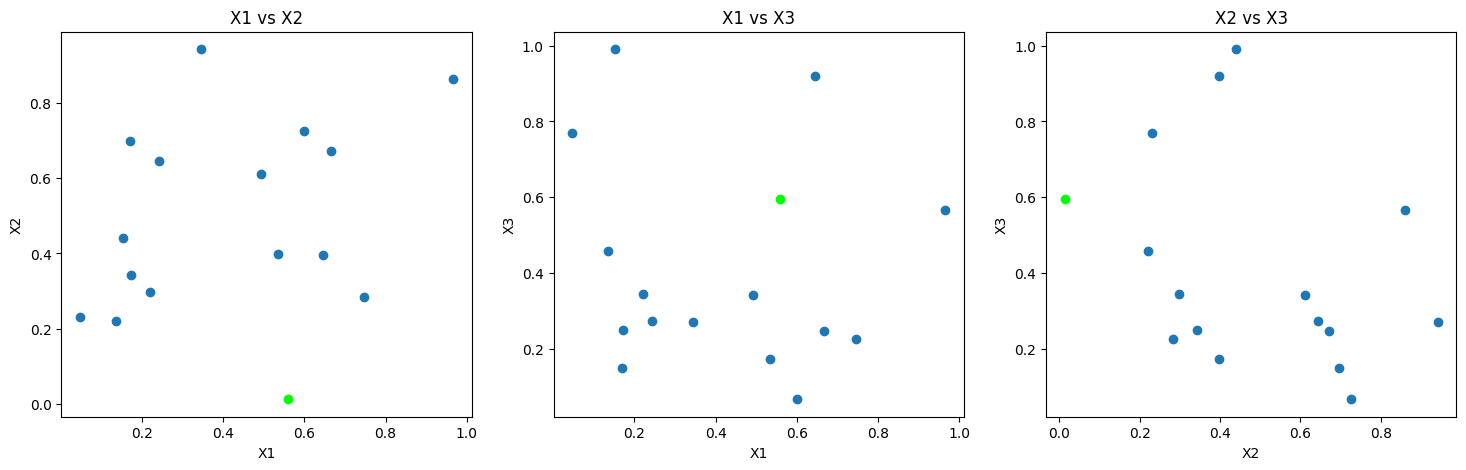

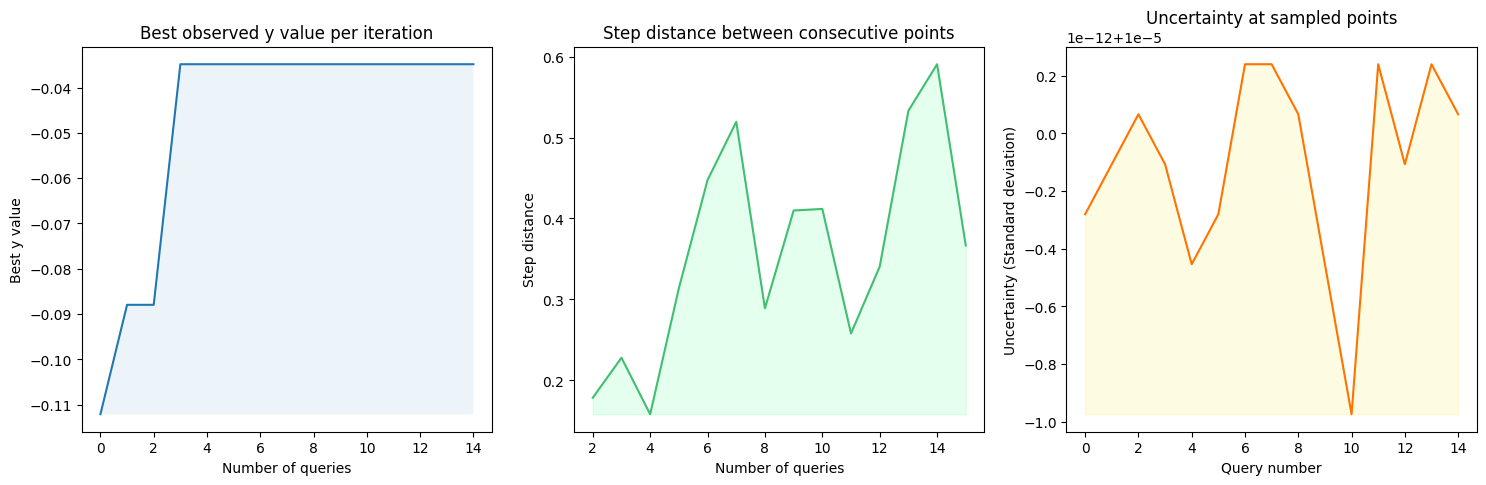

In [4]:
# Defining GP model and fitting to data
kernel = ConstantKernel(1.0) * RBF(length_scale=1)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9) # Look at parameters, some are interesting like normalise y.

model = gpr.fit(X, y)


# Generating candidate points (grid search)
X_candidates = np.random.uniform(0, 1, (20000, 3))

# GP predictions
mu, sigma = model.predict(X_candidates, return_std=True)

# Acquisition function (UCB)
kappa = 1.5
acquisition_function = mu + kappa * sigma

# Pick next point
x_next = X_candidates[np.argmax(acquisition_function)]

print('The next query point is:', np.round(x_next,6))




# ==== Metrics ====

# Best value
best_value3_rolling = np.maximum.accumulate(y)
best_value3 = max(best_value3_rolling)
print('\nThe best y value observed so far is:', best_value3)

# Improvement per step
#improvement_t = y[t] - max(y[:t]) can implement this after week 1

# Distance between sampled points
distances = pdist(X)
avg_distances = np.mean(distances)
min_distance = np.min(distances)

# Step distance between consecutive points
step_dist = np.zeros((len(X)+1))
step_dist[:2] = np.nan
for i in range(1, len(X)):
    step_dist[i+1] = np.linalg.norm(X[i] - X[i-1])
step_distance_normalised = step_dist / np.sqrt(3)
step_dist_min = step_distance_normalised[2:].min()

# Uncertainty at sampled points
mu_selected, sigma_selected = model.predict(X, return_std=True)



# ==== Visualisation ====

# Pair plots

fig, axes = plt.subplots(1,3, figsize=(18, 5))

axes[0].scatter(X[:,0], X[:,1])
axes[0].scatter(x_next[0], x_next[1], c='#00FF00')
axes[0].set_xlabel('X1')
axes[0].set_ylabel('X2')
axes[0].set_title('X1 vs X2')


axes[1].scatter(X[:,0], X[:,2])
axes[1].scatter(x_next[0], x_next[2], c='#00FF00')
axes[1].set_xlabel('X1')
axes[1].set_ylabel('X3')
axes[1].set_title('X1 vs X3')

axes[2].scatter(X[:,1], X[:,2])
axes[2].scatter(x_next[1], x_next[2], c='#00FF00')
axes[2].set_xlabel('X2')
axes[2].set_ylabel('X3')
axes[2].set_title('X2 vs X3')

fig, axes = plt.subplots(1,3, figsize=(18, 5))

# Optimisation curve
axes[0].plot(best_value3_rolling)
axes[0].set_xlabel('Number of queries')
axes[0].set_ylabel('Best y value')
axes[0].set_title('Best observed y value per iteration')
axes[0].fill_between(np.arange(0,len(X),1), best_value3_rolling, best_value3_rolling.min(), alpha=0.08)

# Step distances
axes[1].plot(step_distance_normalised, c="#41BE71")
axes[1].set_xlabel('Number of queries')
axes[1].set_ylabel('Step distance')
axes[1].set_title('Step distance between consecutive points')
axes[1].fill_between(np.arange(0,len(step_dist),1), step_distance_normalised, step_dist_min, color='#05FF65',alpha=0.1)

# Uncertainty at sampled points
axes[2].plot(sigma_selected, c="#FF7300")
axes[2].set_xlabel('Query number')
axes[2].set_ylabel('Uncertainty (Standard deviation)')
axes[2].set_title('Uncertainty at sampled points')
axes[2].fill_between(np.arange(0,len(sigma_selected),1), sigma_selected, sigma_selected.min(), color="#F8E539", alpha=0.15)

plt.show()

## Function 4

**4-dimensional**

Address the challenge of optimally placing products across warehouses for a business with high online sales, where accurate calculations are costly and only feasible biweekly. To speed up decision-making, an ML model approximates these results within hours. The model has four hyperparameters to tune, and its output reflects the difference from the expensive baseline. Because the system is dynamic and full of local optima, it requires careful tuning and robust validation to find reliable, near-optimal solutions.

**Approach**:

Many maxima - start with high kappa and slower decay, add random exploration.
Kernel - Matern(v=1.5 or 2.5) since the function is less smooth.

In [5]:
function4_inputs = np.load('C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/initial_data/function_4/initial_inputs.npy')
print('Inputs: \n', function4_inputs)

function4_outputs = np.load('C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/initial_data/function_4/initial_outputs.npy')
print('Outputs: \n',function4_outputs)

X = function4_inputs
y = function4_outputs

print(len(X), len(y))

Inputs: 
 [[0.89698105 0.72562797 0.17540431 0.70169437]
 [0.8893564  0.49958786 0.53926886 0.50878344]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.80130271 0.50023109 0.70664456 0.19510284]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.74670224 0.7570915  0.36935306 0.20656628]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.6260706  0.58675126 0.43880578 0.77885769]
 [0.95713529 0.59764438 0.76611385 0.77620991]
 [0.73281243 0.14524998 0.47681272 0.13336573]
 [0.65511548 0.07239183 0.68715175 0.08151656]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.48859419 0.2119651  0.93917791 0.37619173]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.98562189 0.66693268 0.15678328 0.8565348 ]
 [0.03782483 0.66485335 0.16198218 0.25392378]
 [0.68348638 0.9027701  0.33541983 0.99948256]
 [0

c:\Python\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


The next query point is: [0.456538 0.2754   0.150867 0.983147]

The best y value observed so far is: -4.025542281908162


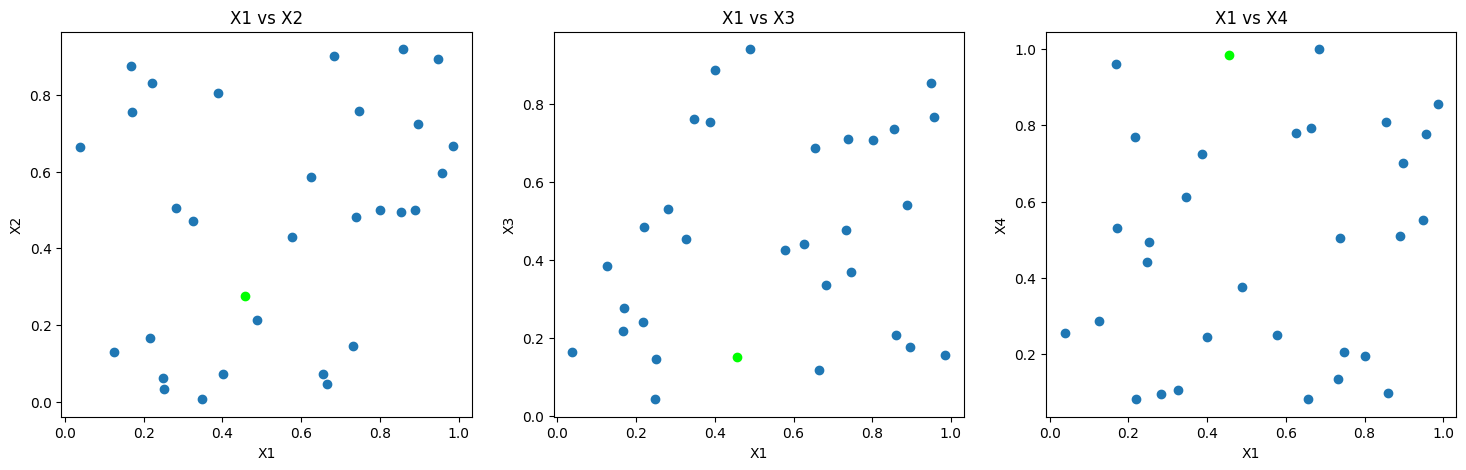

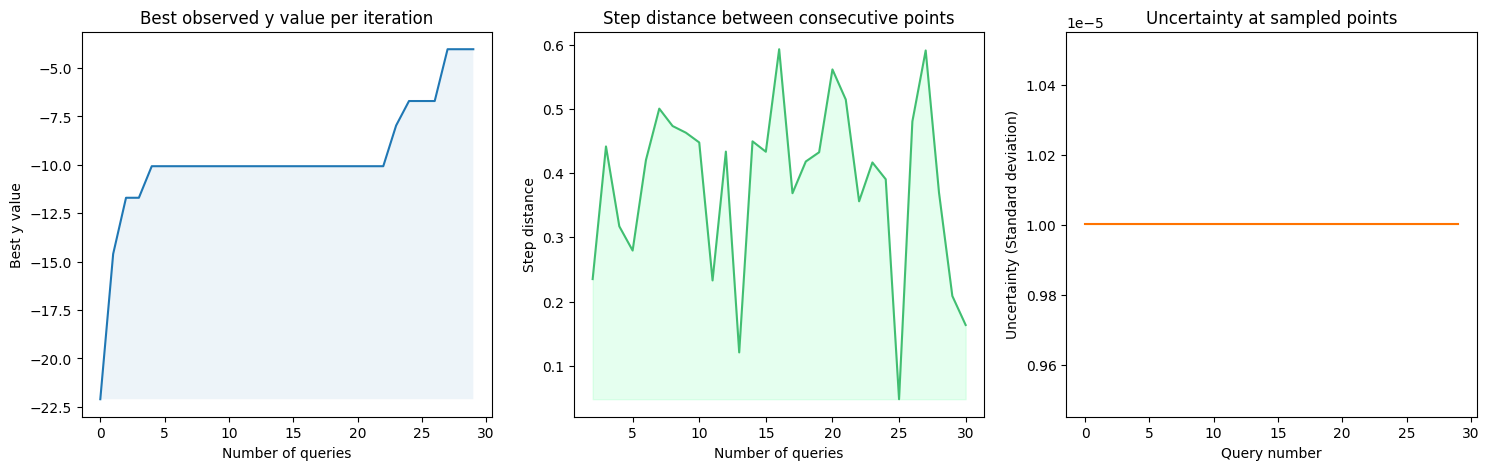

In [6]:
# Defining GP model and fitting to data
kernel = ConstantKernel(1.0) * Matern(length_scale=1, nu=2.5)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9) # Look at parameters, some are interesting like normalise y.

model = gpr.fit(X, y)

# Generating candidate points - smart search, scales much better in higher dimensions.
#X_candidates = np.random.uniform(0,1,(5000, 4))
sampler = qmc.Sobol(4) # Using smarter sampling
X_candidates = sampler.random(2**15)

# GP predictions
mu, sigma = model.predict(X_candidates, return_std=True)

# Acquisition function (UCB)
kappa = 2.5
acquisition_function = mu + kappa * sigma 

# Pick next point
x_next = X_candidates[np.argmax(acquisition_function)]

print('The next query point is:', np.round(x_next,6))



# ==== Metrics ====

# Best value
best_value3_rolling = np.maximum.accumulate(y)
best_value3 = max(best_value3_rolling)
print('\nThe best y value observed so far is:', best_value3)

# Improvement per step
#improvement_t = y[t] - max(y[:t]) can implement this after week 1

# Distance between sampled points
distances = pdist(X)
avg_distances = np.mean(distances)
min_distance = np.min(distances)

# Step distance between consecutive points
step_dist = np.zeros((len(X)+1))
step_dist[:2] = np.nan
for i in range(1, len(X)):
    step_dist[i+1] = np.linalg.norm(X[i] - X[i-1])
step_dist_normalised = step_dist / np.sqrt(4)
step_dist_min = step_dist_normalised[2:].min()

# Uncertainty at sampled points
mu_selected, sigma_selected = model.predict(X, return_std=True)



# ==== Visualisation ====

# Pair plots

fig, axes = plt.subplots(1,3, figsize=(18, 5))

axes[0].scatter(X[:,0], X[:,1])
axes[0].scatter(x_next[0], x_next[1], c='#00FF00')
axes[0].set_xlabel('X1')
axes[0].set_ylabel('X2')
axes[0].set_title('X1 vs X2')

axes[1].scatter(X[:,0], X[:,2])
axes[1].scatter(x_next[0], x_next[2], c='#00FF00')
axes[1].set_xlabel('X1')
axes[1].set_ylabel('X3')
axes[1].set_title('X1 vs X3')

axes[2].scatter(X[:,0], X[:,3])
axes[2].scatter(x_next[0], x_next[3], c='#00FF00')
axes[2].set_xlabel('X1')
axes[2].set_ylabel('X4')
axes[2].set_title('X1 vs X4')

fig, axes = plt.subplots(1,3, figsize=(18, 5))

# Optimisation curve
axes[0].plot(best_value3_rolling)
axes[0].set_xlabel('Number of queries')
axes[0].set_ylabel('Best y value')
axes[0].set_title('Best observed y value per iteration')
axes[0].fill_between(np.arange(0,len(X),1), best_value3_rolling, best_value3_rolling.min(), alpha=0.08)

# Step distances
axes[1].plot(step_dist_normalised, c="#41BE71")
axes[1].set_xlabel('Number of queries')
axes[1].set_ylabel('Step distance')
axes[1].set_title('Step distance between consecutive points')
axes[1].fill_between(np.arange(0,len(step_dist),1), step_dist_normalised, step_dist_min, color='#05FF65',alpha=0.1)

# Uncertainty at sampled points
axes[2].plot(sigma_selected, c="#FF7300")
axes[2].set_xlabel('Query number')
axes[2].set_ylabel('Uncertainty (Standard deviation)')
axes[2].set_title('Uncertainty at sampled points')
axes[2].fill_between(np.arange(0,len(sigma_selected),1), sigma_selected, sigma_selected.min(), color="#F8E539", alpha=0.15)

plt.show()

## Function 5

**4-dimensional**

You’re tasked with optimising a four-variable black-box function that represents the yield of a chemical process in a factory. The function is typically unimodal, with a single peak where yield is maximised. 
Your goal is to find the optimal combination of chemical inputs that delivers the highest possible yield, using systematic exploration and optimisation methods.

**Approach**:

Unimodal, so start with low kappa, potentially switch to EI early. RBF kernel.

In [ ]:
function5_inputs = np.load('C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/initial_data/function_5/initial_inputs.npy')
print('Inputs: \n', function5_inputs)

function5_outputs = np.load('C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/initial_data/function_5/initial_outputs.npy')
print('Outputs: \n',function5_outputs)

X = function5_inputs
y = function5_outputs

print(len(X), len(y))

Inputs: 
 [[0.19144708 0.03819337 0.60741781 0.41458414]
 [0.75865295 0.53651774 0.65600038 0.36034155]
 [0.43834987 0.8043397  0.21024527 0.15129482]
 [0.70605083 0.53419196 0.26424335 0.48208755]
 [0.83647799 0.19360965 0.6638927  0.78564888]
 [0.68343225 0.11866264 0.82904591 0.56757661]
 [0.55362148 0.66734998 0.32380582 0.81486975]
 [0.35235627 0.32224153 0.11697937 0.47311252]
 [0.15378571 0.72938169 0.42259844 0.44307417]
 [0.46344227 0.63002451 0.10790646 0.9576439 ]
 [0.67749115 0.35850951 0.47959222 0.07288048]
 [0.58397341 0.14724265 0.34809746 0.42861465]
 [0.30688872 0.31687813 0.62263448 0.09539906]
 [0.51114177 0.817957   0.72871042 0.11235362]
 [0.43893338 0.77409176 0.37816709 0.93369621]
 [0.22418902 0.84648049 0.87948418 0.87851568]
 [0.72526172 0.47987049 0.08894684 0.75976022]
 [0.35548161 0.63961937 0.41761768 0.12260384]
 [0.11987923 0.86254031 0.64333133 0.84980383]
 [0.12688467 0.15342962 0.77016219 0.19051811]]
Outputs: 
 [6.44434399e+01 1.83013796e+01 1.12939

c:\Python\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


The next query point is: [0.39689026 0.35336638 0.23759587 0.1284783 ]

The best y value observed so far is: 1088.8596181962705


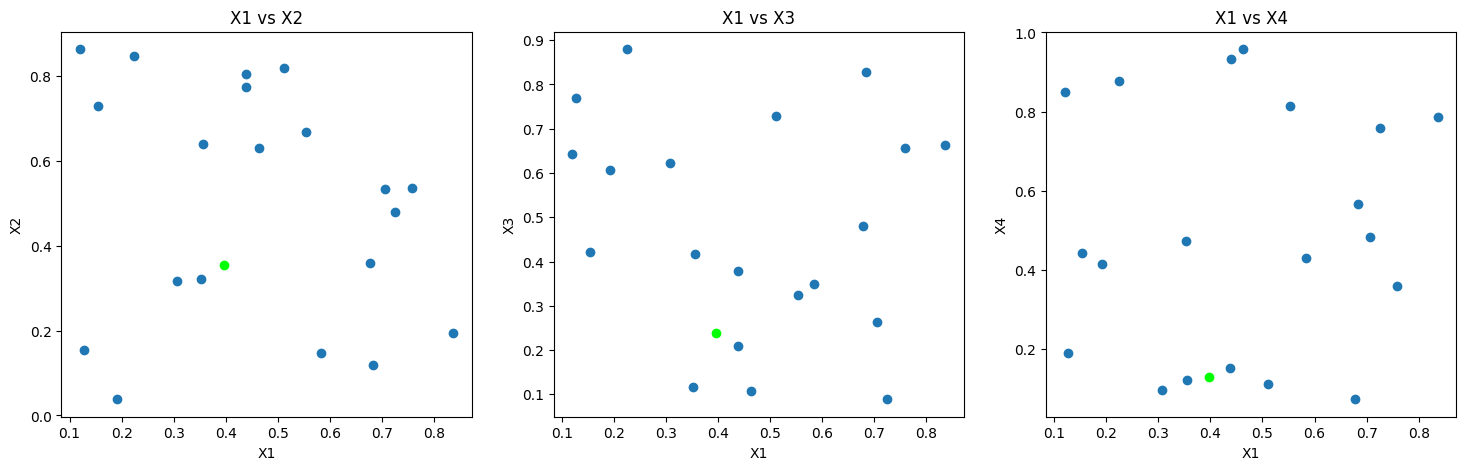

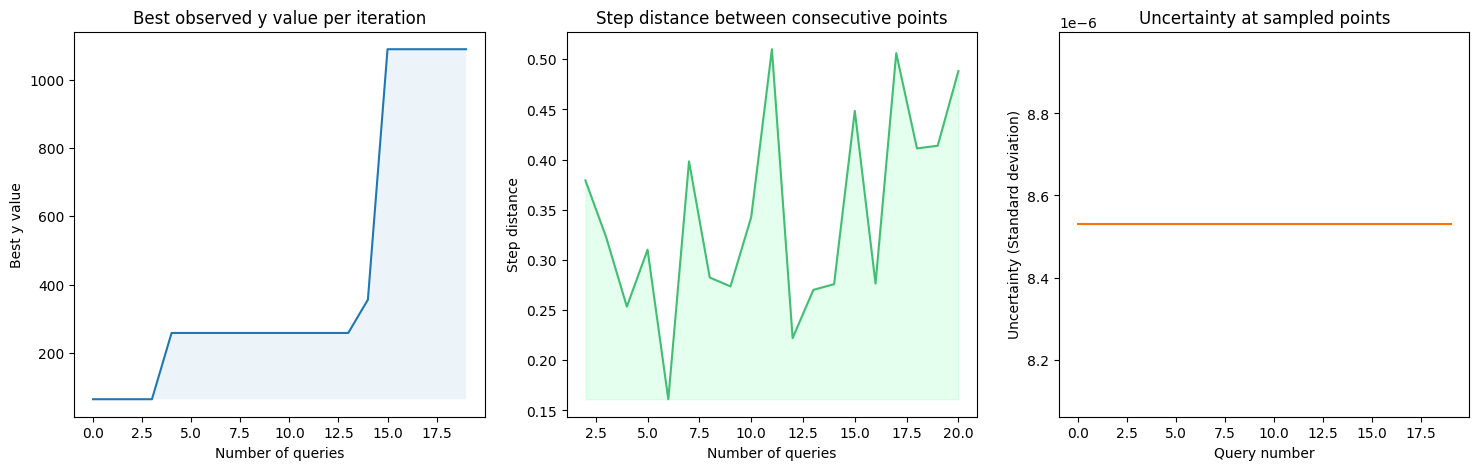

In [ ]:
# Defining GP model and fitting to data
kernel = ConstantKernel(1.0) * RBF(length_scale=1)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=12) # Look at parameters, some are interesting like normalise y.

model = gpr.fit(X, y)

# Generating candidate points (random sampling - scales better in higher dimensions)
sampler = qmc.Sobol(4) # Using smarter sampling
X_candidates = sampler.random(2**15)

# GP predictions
mu, sigma = model.predict(X_candidates, return_std=True)

# Acquisition function (UCB)
kappa = 1.5
acquisition_function = mu + kappa * sigma 

# Pick next point
x_next = X_candidates[np.argmax(acquisition_function)]

print('The next query point is:', np.round(x_next,6))



# ==== Metrics ====

# Best value
best_value3_rolling = np.maximum.accumulate(y)
best_value3 = max(best_value3_rolling)
print('\nThe best y value observed so far is:', best_value3)

# Improvement per step
#improvement_t = y[t] - max(y[:t]) can implement this after week 1

# Distance between sampled points
distances = pdist(X, 'euclidean')
avg_distances = np.mean(distances)
min_distance = np.min(distances)

# Step distance between consecutive points
step_dist = np.zeros((len(X)+1))
step_dist[:2] = np.nan
for i in range(1, len(X)):
    step_dist[i+1] = np.linalg.norm(X[i] - X[i-1])
step_dist_normalised = step_dist / np.sqrt(4)
step_dist_min = step_dist_normalised[2:].min()

# Uncertainty at sampled points
mu_selected, sigma_selected = model.predict(X, return_std=True)



# ==== Visualisation ====

# Pair plots

fig, axes = plt.subplots(1,3, figsize=(18, 5))

axes[0].scatter(X[:,0], X[:,1])
axes[0].scatter(x_next[0], x_next[1], c='#00FF00')
axes[0].set_xlabel('X1')
axes[0].set_ylabel('X2')
axes[0].set_title('X1 vs X2')


axes[1].scatter(X[:,0], X[:,2])
axes[1].scatter(x_next[0], x_next[2], c='#00FF00')
axes[1].set_xlabel('X1')
axes[1].set_ylabel('X3')
axes[1].set_title('X1 vs X3')

axes[2].scatter(X[:,0], X[:,3])
axes[2].scatter(x_next[0], x_next[3], c='#00FF00')
axes[2].set_xlabel('X1')
axes[2].set_ylabel('X4')
axes[2].set_title('X1 vs X4')

fig, axes = plt.subplots(1,3, figsize=(18, 5))

# Optimisation curve
axes[0].plot(best_value3_rolling)
axes[0].set_xlabel('Number of queries')
axes[0].set_ylabel('Best y value')
axes[0].set_title('Best observed y value per iteration')
axes[0].fill_between(np.arange(0,len(X),1), best_value3_rolling, best_value3_rolling.min(), alpha=0.08)

# Step distances
axes[1].plot(step_dist_normalised, c="#41BE71")
axes[1].set_xlabel('Number of queries')
axes[1].set_ylabel('Step distance')
axes[1].set_title('Step distance between consecutive points')
axes[1].fill_between(np.arange(0,len(step_dist),1), step_dist_normalised, step_dist_min, color='#05FF65',alpha=0.1)

# Uncertainty at sampled points
axes[2].plot(sigma_selected, c="#FF7300")
axes[2].set_xlabel('Query number')
axes[2].set_ylabel('Uncertainty (Standard deviation)')
axes[2].set_title('Uncertainty at sampled points')
axes[2].fill_between(np.arange(0,len(sigma_selected),1), sigma_selected, sigma_selected.min(), color="#F8E539", alpha=0.15)

plt.show()

## Function 6

**5-dimensional**

You’re optimising a cake recipe using a black-box function with five ingredient inputs, for example flour, sugar, eggs, butter and milk. Each recipe is evaluated with a combined score based on flavour, consistency, calories, waste and cost, where each factor contributes negative points as judged by an expert taster. This means the total score is negative by design. 
To frame this as a maximisation problem, your goal is to bring that score as close to zero as possible or, equivalently, to maximise the negative of the total sum.

**Approach**:

Start with high kappa. RBF kernel.

In [ ]:
function6_inputs = np.load('C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/initial_data/function_6/initial_inputs.npy')
print('Inputs: \n', function6_inputs)

function6_outputs = np.load('C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/initial_data/function_6/initial_outputs.npy')
print('Outputs: \n',function6_outputs)

X = function6_inputs
y = function6_outputs

print(len(X), len(y))

Inputs: 
 [[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.70499988 0.61496184]
 [0.

The next query point is: [0.0558075  0.12682457 0.1565993  0.92718209 0.03935344]

The best y value observed so far is: -0.7142649478202404


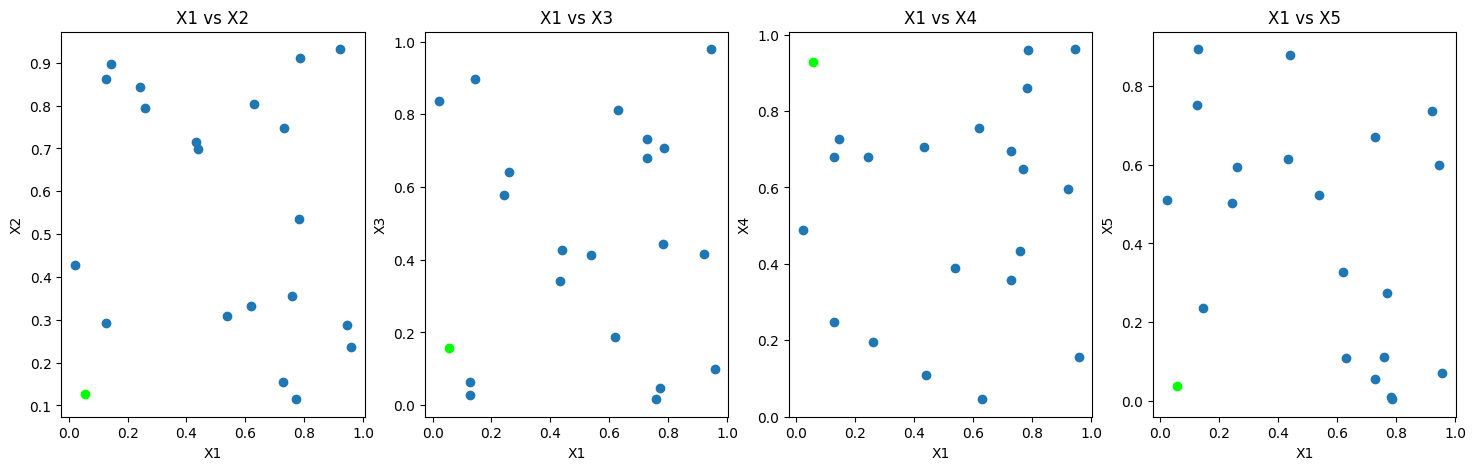

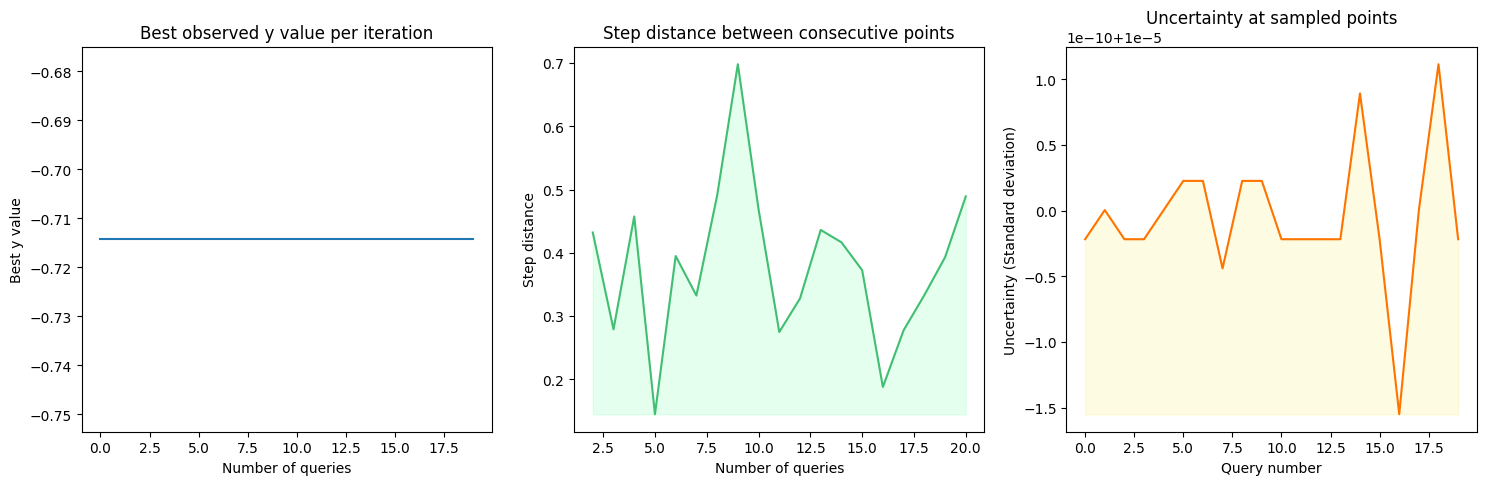

In [ ]:
# Defining GP model and fitting to data
kernel = ConstantKernel(1.0) * RBF(length_scale=1)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9) # Look at parameters, some are interesting like normalise y.

model = gpr.fit(X, y)

# Generating candidate points (grid search)
sampler = qmc.Sobol(5) # Using smarter sampling
X_candidates = sampler.random(2**15)

# GP predictions
mu, sigma = model.predict(X_candidates, return_std=True)

# Acquisition function (UCB)
kappa = 1.5
acquisition_function = mu + kappa * sigma 

# Pick next point
x_next = X_candidates[np.argmax(acquisition_function)]

print('The next query point is:', np.round(x_next,6))



# ==== Metrics ====

# Best value
best_value3_rolling = np.maximum.accumulate(y)
best_value3 = max(best_value3_rolling)
print('\nThe best y value observed so far is:', best_value3)

# Improvement per step
#improvement_t = y[t] - max(y[:t]) can implement this after week 1

# Distance between sampled points
distances = pdist(X)
avg_distances = np.mean(distances)
min_distance = np.min(distances)

# Step distance between consecutive points
step_dist = np.zeros((len(X)+1))
step_dist[:2] = np.nan
for i in range(1, len(X)):
    step_dist[i+1] = np.linalg.norm(X[i] - X[i-1])
step_dist_normalised = step_dist / np.sqrt(5)
step_dist_min = step_dist_normalised[2:].min()

# Uncertainty at sampled points
mu_selected, sigma_selected = model.predict(X, return_std=True)



# ==== Visualisation ====

# Pair plots

fig, axes = plt.subplots(1,4, figsize=(18, 5))

axes[0].scatter(X[:,0], X[:,1])
axes[0].scatter(x_next[0], x_next[1], c='#00FF00')
axes[0].set_xlabel('X1')
axes[0].set_ylabel('X2')
axes[0].set_title('X1 vs X2')

axes[1].scatter(X[:,0], X[:,2])
axes[1].scatter(x_next[0], x_next[2], c='#00FF00')
axes[1].set_xlabel('X1')
axes[1].set_ylabel('X3')
axes[1].set_title('X1 vs X3')

axes[2].scatter(X[:,0], X[:,3])
axes[2].scatter(x_next[0], x_next[3], c='#00FF00')
axes[2].set_xlabel('X1')
axes[2].set_ylabel('X4')
axes[2].set_title('X1 vs X4')

axes[3].scatter(X[:,0], X[:,4])
axes[3].scatter(x_next[0], x_next[4], c='#00FF00')
axes[3].set_xlabel('X1')
axes[3].set_ylabel('X5')
axes[3].set_title('X1 vs X5')

# Metric curves

fig, axes = plt.subplots(1,3, figsize=(18, 5))

# Optimisation curve
axes[0].plot(best_value3_rolling)
axes[0].set_xlabel('Number of queries')
axes[0].set_ylabel('Best y value')
axes[0].set_title('Best observed y value per iteration')
axes[0].fill_between(np.arange(0,len(X),1), best_value3_rolling, best_value3_rolling.min(), alpha=0.08)

# Step distances
axes[1].plot(step_dist_normalised, c="#41BE71")
axes[1].set_xlabel('Number of queries')
axes[1].set_ylabel('Step distance')
axes[1].set_title('Step distance between consecutive points')
axes[1].fill_between(np.arange(0,len(step_dist),1), step_dist_normalised, step_dist_min, color='#05FF65',alpha=0.1)

# Uncertainty at sampled points
axes[2].plot(sigma_selected, c="#FF7300")
axes[2].set_xlabel('Query number')
axes[2].set_ylabel('Uncertainty (Standard deviation)')
axes[2].set_title('Uncertainty at sampled points')
axes[2].fill_between(np.arange(0,len(sigma_selected),1), sigma_selected, sigma_selected.min(), color="#F8E539", alpha=0.15)

plt.show()

## Function 7

**6-dimensional**

You’re tasked with optimising an ML model by tuning six hyperparameters, for example learning rate, regularisation strength or number of hidden layers. The function you’re maximising is the model’s performance score (such as accuracy or F1), but since the relationship between inputs and output isn’t known, it’s treated as a black-box function. 
Because this is a commonly used model, you might benefit from researching best practices or literature to guide your initial search space. Your goal is to find the combination of hyperparameters that yields the highest possible performance.

**Approach**:

Likely start with high kappa, potentially use Matern kernel.

Look up best practices for this.

In [ ]:
function7_inputs = np.load('C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/initial_data/function_7/initial_inputs.npy')
print('Inputs: \n', function7_inputs)

function7_outputs = np.load('C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/initial_data/function_7/initial_outputs.npy')
print('Outputs: \n',function7_outputs)

X = function7_inputs
y = function7_outputs

print(len(X), len(y))

Inputs: 
 [[0.27262382 0.32449536 0.89710881 0.83295115 0.15406269 0.79586362]
 [0.54300258 0.9246939  0.34156746 0.64648585 0.71844033 0.34313266]
 [0.09083225 0.66152938 0.06593091 0.25857701 0.96345285 0.6402654 ]
 [0.11886697 0.61505494 0.90581639 0.8553003  0.41363143 0.58523563]
 [0.63021764 0.8380969  0.68001305 0.73189509 0.52673671 0.34842921]
 [0.76491917 0.25588292 0.60908422 0.21807904 0.32294277 0.09579366]
 [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
 [0.19525188 0.07922665 0.55458046 0.17056682 0.01494418 0.10703171]
 [0.64230298 0.83687455 0.02179269 0.10148801 0.68307083 0.6924164 ]
 [0.78994255 0.19554501 0.57562333 0.07365919 0.25904917 0.05109986]
 [0.52849733 0.45742436 0.36009569 0.36204551 0.81689098 0.63747637]
 [0.72261522 0.01181284 0.06364591 0.16517311 0.07924415 0.35995166]
 [0.07566492 0.33450212 0.13273274 0.60831236 0.91838592 0.82233079]
 [0.94245084 0.37743962 0.48612233 0.22879108 0.08263175 0.71195755]
 [0.14864702 0.03394336 

The next query point is: [0.07466396 0.44837361 0.25674983 0.11434814 0.29410908 0.86230382]

The best y value observed so far is: 1.3649683044991994


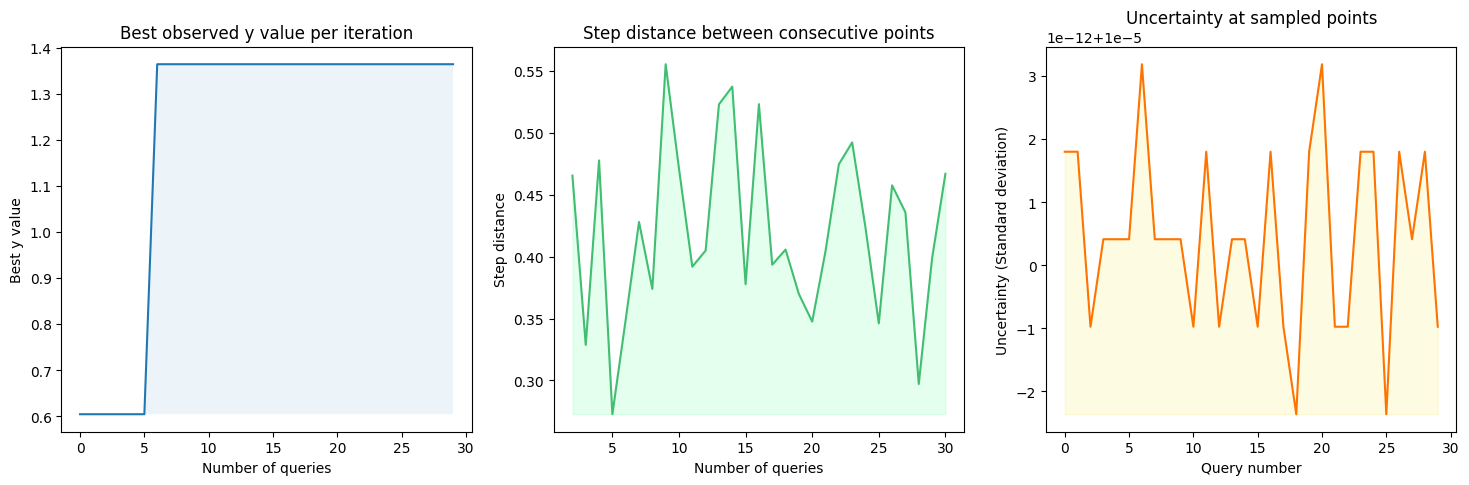

In [ ]:
# Defining GP model and fitting to data
kernel = ConstantKernel(1.0) * Matern(length_scale=1, nu=2.5)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9) # Look at parameters, some are interesting like normalise y.

model = gpr.fit(X, y)

# Generating candidate points (grid search)
sampler = qmc.Sobol(6) # Using smarter sampling
X_candidates = sampler.random(2**15)

# GP predictions
mu, sigma = model.predict(X_candidates, return_std=True)

# Acquisition function (UCB)
kappa = 2
acquisition_function = mu + kappa * sigma 

# Pick next point
x_next = X_candidates[np.argmax(acquisition_function)]

print('The next query point is:', np.round(x_next,6))



# ==== Metrics ====

# Best value
best_value3_rolling = np.maximum.accumulate(y)
best_value3 = max(best_value3_rolling)
print('\nThe best y value observed so far is:', best_value3)

# Improvement per step
#improvement_t = y[t] - max(y[:t]) can implement this after week 1

# Distance between sampled points
distances = pdist(X)
avg_distances = np.mean(distances)
min_distance = np.min(distances)

# Step distance between consecutive points
step_dist = np.zeros((len(X)+1))
step_dist[:2] = np.nan
for i in range(1, len(X)):
    step_dist[i+1] = np.linalg.norm(X[i] - X[i-1])
step_dist_normalised = step_dist / np.sqrt(6)
step_dist_min = step_dist_normalised[2:].min()

# Uncertainty at sampled points
mu_selected, sigma_selected = model.predict(X, return_std=True)



# ==== Visualisation ====

fig, axes = plt.subplots(1,3, figsize=(18, 5))

# Optimisation curve
axes[0].plot(best_value3_rolling)
axes[0].set_xlabel('Number of queries')
axes[0].set_ylabel('Best y value')
axes[0].set_title('Best observed y value per iteration')
axes[0].fill_between(np.arange(0,len(X),1), best_value3_rolling, best_value3_rolling.min(), alpha=0.08)

# Step distances
axes[1].plot(step_dist_normalised, c="#41BE71")
axes[1].set_xlabel('Number of queries')
axes[1].set_ylabel('Step distance')
axes[1].set_title('Step distance between consecutive points')
axes[1].fill_between(np.arange(0,len(step_dist),1), step_dist_normalised, step_dist_min, color='#05FF65',alpha=0.1)

# Uncertainty at sampled points
axes[2].plot(sigma_selected, c="#FF7300")
axes[2].set_xlabel('Query number')
axes[2].set_ylabel('Uncertainty (Standard deviation)')
axes[2].set_title('Uncertainty at sampled points')
axes[2].fill_between(np.arange(0,len(sigma_selected),1), sigma_selected, sigma_selected.min(), color="#F8E539", alpha=0.15)

plt.show()

## Function 8

**8-dimensional**

You’re optimising an eight-dimensional black-box function, where each of the eight input parameters affects the output, but the internal mechanics are unknown. 
Your objective is to find the parameter combination that maximises the function’s output, such as performance, efficiency or validation accuracy. Because the function is high-dimensional and likely complex, global optimisation is hard, so identifying strong local maxima is often a practical strategy.

For example, imagine you’re tuning an ML model with eight hyperparameters: learning rate, batch size, number of layers, dropout rate, regularisation strength, activation function (numerically encoded), optimiser type (encoded) and initial weight range. Each input set returns a single validation accuracy score between 0 and 1. Your goal is to maximise this score.

**Approach**:

Likely to be lots of local maximum, start with high kappa + random search, using matern kernel.

In [ ]:
function8_inputs = np.load('C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/initial_data/function_8/initial_inputs.npy')
print('Inputs: \n', function8_inputs)

function8_outputs = np.load('C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/initial_data/function_8/initial_outputs.npy')
print('Outputs: \n',function8_outputs)

X = function8_inputs
y = function8_outputs

print(len(X), len(y))

Inputs: 
 [[0.60499445 0.29221502 0.90845275 0.35550624 0.20166872 0.57533801
  0.31031095 0.73428138]
 [0.17800696 0.56622265 0.99486184 0.21032501 0.32015266 0.70790879
  0.63538449 0.10713163]
 [0.00907698 0.81162615 0.52052036 0.07568668 0.26511183 0.09165169
  0.59241515 0.36732026]
 [0.50602816 0.65373012 0.36341078 0.17798105 0.0937283  0.19742533
  0.7558269  0.29247234]
 [0.35990926 0.24907568 0.49599717 0.70921498 0.11498719 0.28920692
  0.55729515 0.59388173]
 [0.77881834 0.0034195  0.33798313 0.51952778 0.82090699 0.53724669
  0.5513471  0.66003209]
 [0.90864932 0.0622497  0.23825955 0.76660355 0.13233596 0.99024381
  0.68806782 0.74249594]
 [0.58637144 0.88073573 0.74502075 0.54603485 0.00964888 0.74899176
  0.23090707 0.09791562]
 [0.76113733 0.85467239 0.38212433 0.33735198 0.68970832 0.30985305
  0.63137968 0.04195607]
 [0.9849332  0.69950626 0.9988855  0.18014846 0.58014315 0.23108719
  0.49082694 0.31368272]
 [0.11207131 0.43773566 0.59659878 0.59277563 0.22698177 0.4

The next query point is: [0.1642988  0.14599413 0.03632531 0.10271767 0.8891426  0.12190662
 0.0603695  0.59493099]

The best y value observed so far is: 9.598482002566342


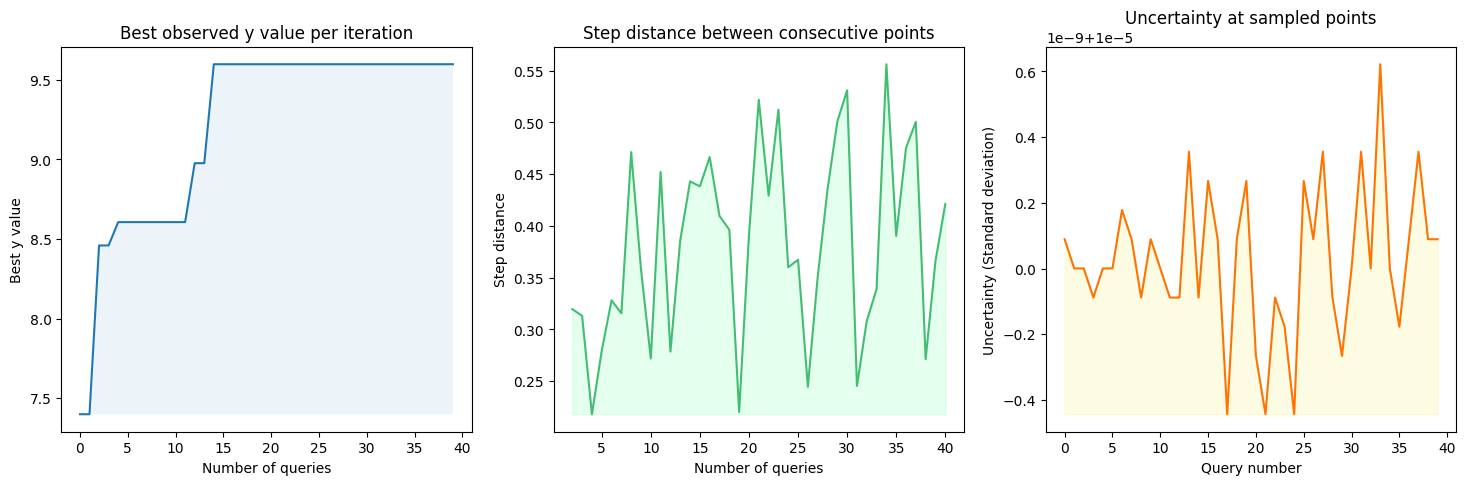

In [ ]:
# Defining GP model and fitting to data
kernel = ConstantKernel(1.0) * Matern(length_scale=1, nu=2.5)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9) # Look at parameters, some are interesting like normalise y.

model = gpr.fit(X, y)

# Generating candidate points
sampler = qmc.Sobol(8) # Using smarter sampling
X_candidates = sampler.random(2**15)

# GP predictions
mu, sigma = model.predict(X_candidates, return_std=True)

# Acquisition function (UCB)
kappa = 2.5
acquisition_function = mu + kappa * sigma 

# Pick next point
x_next = X_candidates[np.argmax(acquisition_function)]

print('The next query point is:', np.round(x_next,6))



# ==== Metrics ====

# Best value
best_value3_rolling = np.maximum.accumulate(y)
best_value3 = max(best_value3_rolling)
print('\nThe best y value observed so far is:', best_value3)

# Improvement per step
#improvement_t = y[t] - max(y[:t]) can implement this after week 1

# Distance between sampled points
distances = pdist(X)
avg_distances = np.mean(distances)
min_distance = np.min(distances)

# Step distance between consecutive points
step_dist = np.zeros((len(X)+1))
step_dist[:2] = np.nan
for i in range(1, len(X)):
    step_dist[i+1] = np.linalg.norm(X[i] - X[i-1])
step_dist_normalised = step_dist / np.sqrt(8)
step_dist_min = step_dist_normalised[2:].min()

# Uncertainty at sampled points
mu_selected, sigma_selected = model.predict(X, return_std=True)



# ==== Visualisation ====

fig, axes = plt.subplots(1,3, figsize=(18, 5))

# Optimisation curve
axes[0].plot(best_value3_rolling)
axes[0].set_xlabel('Number of queries')
axes[0].set_ylabel('Best y value')
axes[0].set_title('Best observed y value per iteration')
axes[0].fill_between(np.arange(0,len(X),1), best_value3_rolling, best_value3_rolling.min(), alpha=0.08)

# Step distances
axes[1].plot(step_dist_normalised, c="#41BE71")
axes[1].set_xlabel('Number of queries')
axes[1].set_ylabel('Step distance')
axes[1].set_title('Step distance between consecutive points')
axes[1].fill_between(np.arange(0,len(step_dist),1), step_dist_normalised, step_dist_min, color='#05FF65',alpha=0.1)

# Uncertainty at sampled points
axes[2].plot(sigma_selected, c="#FF7300")
axes[2].set_xlabel('Query number')
axes[2].set_ylabel('Uncertainty (Standard deviation)')
axes[2].set_title('Uncertainty at sampled points')
axes[2].fill_between(np.arange(0,len(sigma_selected),1), sigma_selected, sigma_selected.min(), color="#F8E539", alpha=0.15)

plt.show()